# Set-up

In [3]:
import os
from collections import defaultdict
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [4]:
import wandb

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("wandb_api")
    wandb.login(key=api_key)
    anony = None
except:
    anony = "must"
    print('If you want to use your W&B account, go to Add-ons -> Secrets and provide your W&B access token. Use the Label name as wandb_api. \nGet your W&B access token from here: https://wandb.ai/authorize')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


# Data prep.

In [5]:
ds_path = '../input/anomaly/dataset'

In [6]:
for root, dirs, paths in os.walk(ds_path):
  print(root, dirs, len(paths))

../input/anomaly/dataset ['proliv', 'test', 'train'] 0
../input/anomaly/dataset/proliv [] 154
../input/anomaly/dataset/test ['imgs'] 1
../input/anomaly/dataset/test/imgs [] 3794
../input/anomaly/dataset/train [] 10000


In [7]:
class anomaly_dataset(Dataset):
  def __init__(self, ds_path, split, annotations_file=None, transform=None):
    self.ds_path = ds_path
    self.split = split.lower()

    if (self.split == 'test' and annotations_file is not None):
      test_images = os.path.join(self.ds_path, 'test', 'imgs')
      test_labels = os.path.join(self.ds_path, 'test', annotations_file)

      self.images_paths = sorted(os.listdir(test_images))
      self.labels_list = []
      with open(test_labels, 'r') as f:
        lines = sorted([line for line in f], key=lambda l: l.split()[0])
        self.labels_list = [int(line.split()[1]) for line in lines]
    else:
      split_path = os.path.join(self.ds_path, self.split)
      self.images_paths = sorted(os.listdir(split_path))

    self.transform = transform

  def __len__(self):
    return len(self.images_paths)

  def __getitem__(self, index):
    if self.split == 'test':
      label = self.labels_list[index]
      image_path = os.path.join(self.ds_path, self.split, 'imgs', self.images_paths[index])
      image = cv2.imread(image_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      image_t = self.transform(image)
      image_t = transforms.functional.adjust_contrast(image_t, contrast_factor=1.5)
      return image_t, label
    else:
      image_path = os.path.join(ds_path, self.split, self.images_paths[index])
      image = cv2.imread(image_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      image_t = self.transform(image)
      image_t = transforms.functional.adjust_contrast(image_t, contrast_factor=1.5)
      return image_t


In [17]:
baseline_tform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((64, 64)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

norm_tform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = anomaly_dataset(ds_path, 'train', transform=baseline_tform)
proliv_ds = anomaly_dataset(ds_path, 'proliv', transform=baseline_tform)
test_ds = anomaly_dataset(ds_path, 'test', 'test_annotation.txt', transform=baseline_tform)
print(len(train_ds), len(proliv_ds), len(test_ds))


10000 154 3794


torch.Size([1, 64, 64])


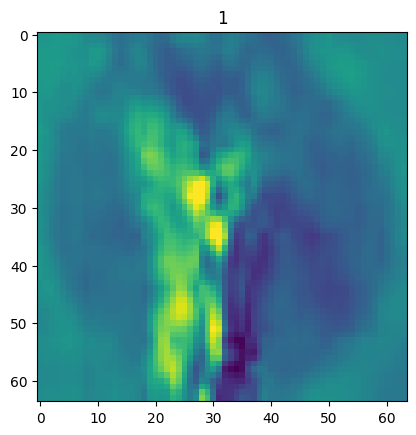

In [18]:
for i in range(len(test_ds)):
  image, label = test_ds[i]
  if i == 1000: break
  if label == 1: break

plt.title(str(label))
plt.imshow(image.squeeze().cpu().numpy())
print(image.shape)

# Baselines

In [21]:
## Linear baseline
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(4096, 1500),
            nn.ReLU(),
            nn.Linear(1500, 784),
            nn.ReLU(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.dec = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.ReLU(),
            nn.Linear(784, 1500),
            nn.ReLU(),
            nn.Linear(1500, 4096),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        encode = self.enc(x)
        decode = self.dec(encode)
        return decode

In [11]:
## Convolution baseline

class AE5(nn.Module):
    def __init__(self, scale_factor=1):
        super(AE5, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, int(32*scale_factor), kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(int(32*scale_factor)),

            nn.Conv2d(int(32*scale_factor), int(64*scale_factor), kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(int(64*scale_factor)),

            nn.Conv2d(int(64*scale_factor), int(128*scale_factor), kernel_size=3, padding=1),
            nn.BatchNorm2d(int(128*scale_factor)),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(int(128*scale_factor), int(64*scale_factor), kernel_size=2, stride=2),  
            nn.ReLU(),
            nn.BatchNorm2d(int(64*scale_factor)),
            nn.ReLU(),
            
            nn.ConvTranspose2d(int(64*scale_factor), int(32*scale_factor), kernel_size=2, stride=2),
            nn.ReLU(),
            nn.BatchNorm2d(int(32*scale_factor)),
            nn.ReLU(),
            
            nn.Conv2d(int(32*scale_factor), 3, kernel_size=3, padding=1),  
            nn.Sigmoid()  
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Linear train loop

In [22]:
from torchinfo import summary
t = torch.randn((1, 1, 64, 64))
model = AE()
r = model(t)
print(r.shape)
summary(model, [1, 1, 64, 64])

torch.Size([1, 4096])


Layer (type:depth-idx)                   Output Shape              Param #
AE                                       [1, 4096]                 --
├─Sequential: 1-1                        [1, 16]                   --
│    └─Linear: 2-1                       [1, 1500]                 6,145,500
│    └─ReLU: 2-2                         [1, 1500]                 --
│    └─Linear: 2-3                       [1, 784]                  1,176,784
│    └─ReLU: 2-4                         [1, 784]                  --
│    └─Linear: 2-5                       [1, 512]                  401,920
│    └─ReLU: 2-6                         [1, 512]                  --
│    └─Linear: 2-7                       [1, 256]                  131,328
│    └─ReLU: 2-8                         [1, 256]                  --
│    └─Linear: 2-9                       [1, 128]                  32,896
│    └─ReLU: 2-10                        [1, 128]                  --
│    └─Linear: 2-11                      [1, 64]         

In [23]:
batch_size = 256
lr = 6e-3
w_d = 1e-6
epochs = 25

In [24]:
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

proliv_dl = DataLoader(
    proliv_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

In [25]:
metrics = defaultdict(list)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model.to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=w_d)

In [26]:
run = wandb.init(
    project="_ae1_train_",
    config={
        "learning_rate": lr,
        "epochs": epochs,
    },
)

In [28]:
start = time.time()
for epoch in tqdm(range(epochs)):
  ep_start = time.time()
  running_loss = 0.0
  model.train()
  for i, data in enumerate(train_dl):
    data = torch.flatten(data.to(device), start_dim=1)
    pred = model(data)
    loss = criterion(data, pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  model.eval()
  # по идее должно падать медленнее
  running_eval_loss = 0.0
  for i, data in enumerate(proliv_dl):
    data = torch.flatten(data.to(device), start_dim=1)
    pred = model(data)
    loss = criterion(data, pred)
    running_eval_loss += loss.item()

  epoch_loss = running_loss/len(train_dl)
  epoch_val_loss = running_eval_loss/len(proliv_dl)
  wandb.log({'epoch': epoch,
             'train_loss': epoch_loss,
             'val_loss': epoch_val_loss})

  metrics['train_loss'].append(epoch_loss)
  metrics['val_loss'].append(epoch_val_loss)
  ep_end = time.time()
  print('\n-----------------------------------------------')
  print(f'epoch: {epoch}\ttrain_loss: {epoch_loss:.5f}\tval_loss: {epoch_val_loss}')
  print(f'epoch completed in {(ep_end-ep_start)/60:.2f} mins')

end = time.time()
print('\n-----------------------------------------------')
print(f'training completed in {(end-start)/60:.2f} mins')

  4%|▍         | 1/25 [00:24<09:37, 24.05s/it]


-----------------------------------------------
epoch: 0	train_loss: 0.00289	val_loss: 0.011367437429726124
epoch completed in 0.40 mins


  8%|▊         | 2/25 [00:31<05:33, 14.51s/it]


-----------------------------------------------
epoch: 1	train_loss: 0.00280	val_loss: 0.011546701192855835
epoch completed in 0.13 mins


 12%|█▏        | 3/25 [00:39<04:14, 11.57s/it]

...


-----------------------------------------------
epoch: 22	train_loss: 0.00276	val_loss: 0.011740406975150108
epoch completed in 0.13 mins


 96%|█████████▌| 24/25 [03:27<00:07,  7.67s/it]


-----------------------------------------------
epoch: 23	train_loss: 0.00275	val_loss: 0.011670651845633984
epoch completed in 0.13 mins


100%|██████████| 25/25 [03:35<00:00,  8.62s/it]


-----------------------------------------------
epoch: 24	train_loss: 0.00280	val_loss: 0.0114687979221344
epoch completed in 0.13 mins

-----------------------------------------------
training completed in 3.59 mins


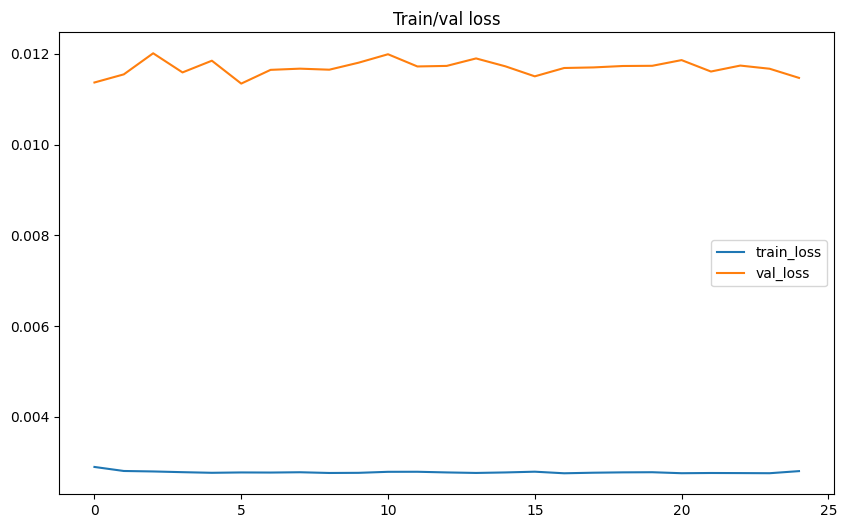

In [29]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train/val loss')
ax.plot(metrics['train_loss'], label='train_loss')
ax.plot(metrics['val_loss'], label='val_loss')
ax.legend()

In [32]:
train_dl = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

proliv_dl = DataLoader(
    proliv_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

loss_dist_pos = []
loss_dist_neg = []

model.eval()

criterion = nn.MSELoss(reduction='mean')

for i, data in tqdm(enumerate(train_dl)):
    data = torch.flatten(data.to(device), start_dim=1)
    pred = model(data)
    loss = criterion(data.to(device), pred)
    loss_dist_neg.append(loss.detach().cpu().numpy())

for i, data in tqdm(enumerate(proliv_dl)):
    data = torch.flatten(data.to(device), start_dim=1)
    pred = model(data)
    loss = criterion(data.to(device), pred)
    loss_dist_pos.append(loss.detach().cpu().numpy())


10000it [00:24, 402.13it/s]
154it [00:00, 368.86it/s]


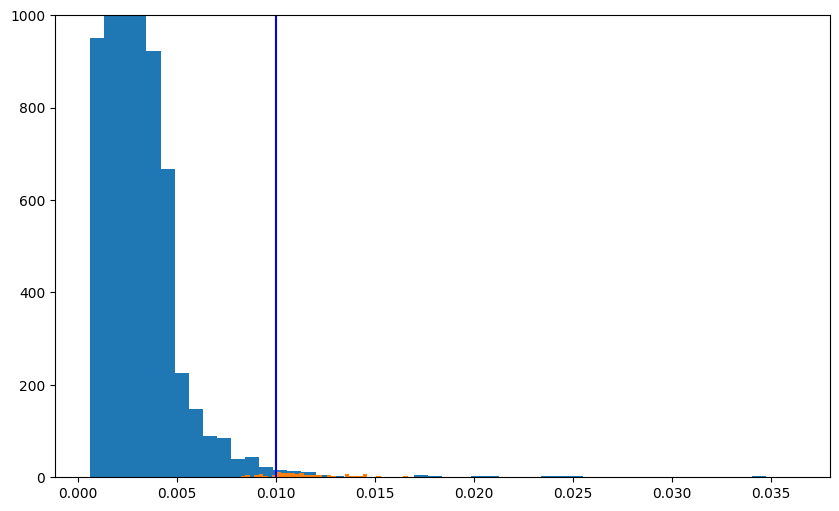

In [36]:
thr = 0.01
plt.figure(figsize=(10, 6))
plt.ylim(0, 1000)
plt.hist(loss_dist_neg, bins=50)
plt.hist(loss_dist_pos, bins=50)

plt.axvline(x=thr, color='b')
plt.show()

# Convolution train loop

In [329]:
from torchinfo import summary
t = torch.randn((1, 3, 64, 64))
model = AE5(scale_factor=1.25)
r = model(t)
print(r.shape)
summary(model, [1, 3, 64, 64])

torch.Size([1, 3, 64, 64])


Layer (type:depth-idx)                   Output Shape              Param #
AE5                                      [1, 3, 64, 64]            --
├─Sequential: 1-1                        [1, 160, 16, 16]          --
│    └─Conv2d: 2-1                       [1, 40, 64, 64]           1,120
│    └─ReLU: 2-2                         [1, 40, 64, 64]           --
│    └─MaxPool2d: 2-3                    [1, 40, 32, 32]           --
│    └─BatchNorm2d: 2-4                  [1, 40, 32, 32]           80
│    └─Conv2d: 2-5                       [1, 80, 32, 32]           28,880
│    └─ReLU: 2-6                         [1, 80, 32, 32]           --
│    └─MaxPool2d: 2-7                    [1, 80, 16, 16]           --
│    └─BatchNorm2d: 2-8                  [1, 80, 16, 16]           160
│    └─Conv2d: 2-9                       [1, 160, 16, 16]          115,360
│    └─BatchNorm2d: 2-10                 [1, 160, 16, 16]          320
│    └─ReLU: 2-11                        [1, 160, 16, 16]          --
├

In [333]:
batch_size = 256
lr = 6e-3
w_d = 1e-6
epochs = 25

In [334]:

tfrom_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.3),
    transforms.RandomVerticalFlip(0.3),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = anomaly_dataset(ds_path, 'train', transform=tfrom_aug)
proliv_ds = anomaly_dataset(ds_path, 'proliv', transform=norm_tform)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

proliv_dl = DataLoader(
    proliv_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

In [335]:
metrics = defaultdict(list)
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model.to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=w_d)

In [336]:
run = wandb.init(
    project="_ae5_train_",
    config={
        "learning_rate": lr,
        "epochs": epochs,
    },
)

In [337]:

start = time.time()
for epoch in tqdm(range(epochs)):
  ep_start = time.time()
  running_loss = 0.0
  model.train()
  for i, data in enumerate(train_dl):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  model.eval()
  # по идее должно падать медленнее
  running_eval_loss = 0.0
  for i, data in enumerate(proliv_dl):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    running_eval_loss += loss.item()

  epoch_loss = running_loss/len(train_dl)
  epoch_val_loss = running_eval_loss/len(proliv_dl)
  wandb.log({'epoch': epoch,
             'train_loss': epoch_loss,
             'val_loss': epoch_val_loss})

  metrics['train_loss'].append(epoch_loss)
  metrics['val_loss'].append(epoch_val_loss)
  ep_end = time.time()
  print('\n-----------------------------------------------')
  print(f'epoch: {epoch}\ttrain_loss: {epoch_loss:.5f}\tval_loss: {epoch_val_loss}')
  print(f'epoch completed in {(ep_end-ep_start)/60:.2f} mins')

end = time.time()
print('\n-----------------------------------------------')
print(f'training completed in {(end-start)/60:.2f} mins')

  4%|▍         | 1/25 [00:13<05:30, 13.76s/it]


-----------------------------------------------
epoch: 0	train_loss: 0.01392	val_loss: 0.026815511286258698
epoch completed in 0.23 mins


  8%|▊         | 2/25 [00:23<04:28, 11.67s/it]


-----------------------------------------------
epoch: 1	train_loss: 0.00209	val_loss: 0.01676413044333458
epoch completed in 0.17 mins


 12%|█▏        | 3/25 [00:34<04:07, 11.25s/it]

...


-----------------------------------------------
epoch: 22	train_loss: 0.00059	val_loss: 0.01352621614933014
epoch completed in 0.17 mins


 96%|█████████▌| 24/25 [04:14<00:10, 10.45s/it]


-----------------------------------------------
epoch: 23	train_loss: 0.00049	val_loss: 0.01374838501214981
epoch completed in 0.17 mins


100%|██████████| 25/25 [04:24<00:00, 10.60s/it]


-----------------------------------------------
epoch: 24	train_loss: 0.00071	val_loss: 0.013466346077620983
epoch completed in 0.17 mins

-----------------------------------------------
training completed in 4.42 mins


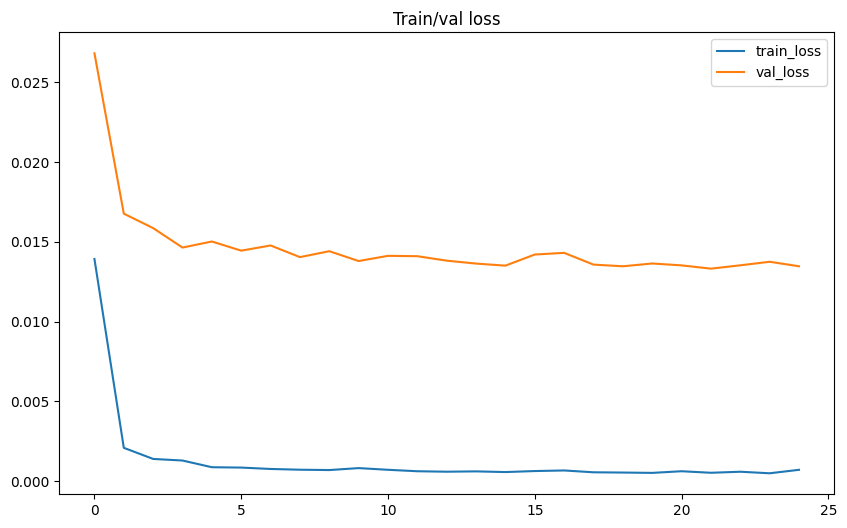

In [338]:
_, ax = plt.subplots(1,1,figsize=(10,6))
ax.set_title('Train/val loss')
ax.plot(metrics['train_loss'], label='train_loss')
ax.plot(metrics['val_loss'], label='val_loss')
ax.legend()

# Threshold

In [362]:
train_dl = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

proliv_dl = DataLoader(
    proliv_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

loss_dist_pos = []
loss_dist_neg = []

model.eval()

criterion = nn.MSELoss(reduction='mean')

for i, data in tqdm(enumerate(train_dl)):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    loss_dist_neg.append(loss.detach().cpu().numpy())

for i, data in tqdm(enumerate(proliv_dl)):
    pred = model(data.to(device))
    loss = criterion(data.to(device), pred)
    loss_dist_pos.append(loss.detach().cpu().numpy())


10000it [00:25, 391.01it/s]
154it [00:00, 335.73it/s]


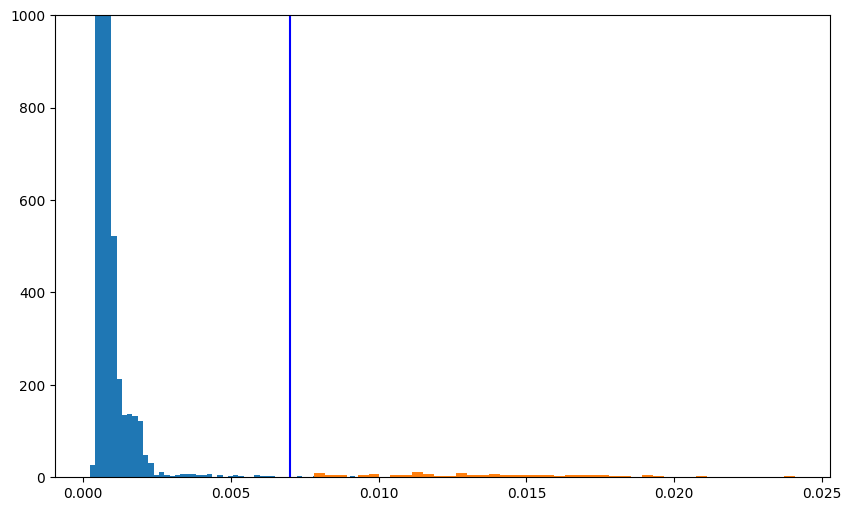

In [368]:
thr = 0.007
plt.figure(figsize=(10, 6))
plt.ylim(0, 1000)
plt.hist(loss_dist_neg, bins=50)
plt.hist(loss_dist_pos, bins=50)

plt.axvline(x=thr, color='b')
plt.show()

# Testing

torch.Size([128, 3, 64, 64]) torch.Size([128, 3, 64, 64])


<Figure size 1600x1200 with 0 Axes>

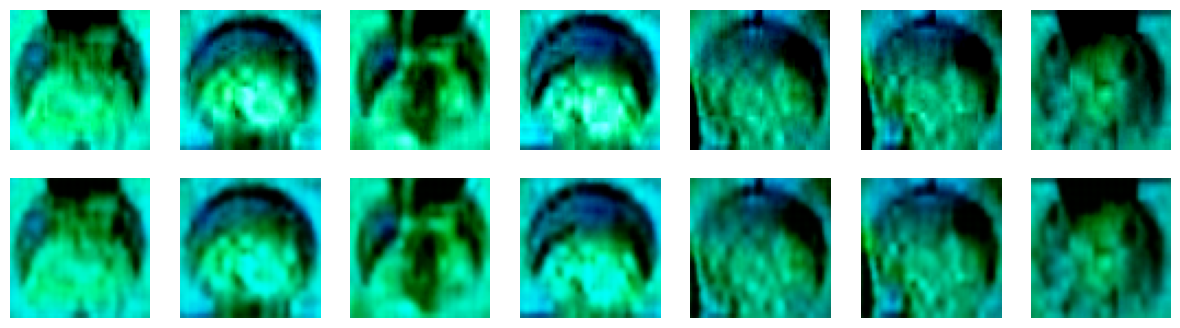

In [370]:
test_dl = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
)

with torch.no_grad():
    for data, labels in test_dl:
        data = data.to(device)
        recon = model(data)
        break

print(data.shape, recon.shape)
plt.figure(dpi=250)
fig, ax = plt.subplots(2, 7, figsize=(15, 4))
for i in range(7):
    ax[0, i].set_xlabel(labels[i])
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[0, i].axis('OFF')
    ax[1, i].axis('OFF')

In [371]:
def predict_label(model, image, thresh, criterion, device):
  pred = model(image.to(device))
  loss = criterion(image.to(device), pred)

  if loss > thresh: return 1
  else: return 0

In [375]:
test_dl = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=True,
    num_workers=2,
)

low_thr = 0.00
high_thr= 0.01
step = 0.00075
cur_thr = low_thr

thrs_all = []

best_thr= -1
best_f1 = -1

metrics = defaultdict(list)
TP, TN, FP, FN = 0, 0, 0, 0
TPR, TNR = 0, 0
model.eval()

while (cur_thr < high_thr):
  thrs_all.append(cur_thr)
  for i, (image, label) in enumerate(test_dl):
    pred_label = predict_label(model, image, cur_thr, criterion, device)

    if label == 0:
      if pred_label == 0: TN += 1
      elif pred_label == 1: FP += 1
    elif label == 1:
      if pred_label == 0: FN += 1
      elif pred_label == 1: TP += 1

  precision = TP / (TP + FP)
  recall = TP / (TP + FN)
  TPR = TP/(TP+FN)
  TNR = TN/(TN+FP)
  f1 = 2 * precision * recall / (precision + recall)

  if f1 > best_f1:
    best_thr = cur_thr
    best_f1 = f1

  metrics['precision'].append(precision)
  metrics['recall'].append(recall)
  metrics['tpr'].append(TPR)
  metrics['tnr'].append(TNR)
  metrics['f1'].append(f1)

  wandb.log({'threshold': thr,
             'precision': precision,
             'recall': recall,
             'tnr': TNR,
             'tpr': TPR,
             'f1': f1})

  print('--------------------------------------------------------------------------------------------------------------\n')
  print(f'threshold: {cur_thr:.6f}\tprecision: {precision:.4f}\trecall: {recall:.4f}\tf1 {f1:.4f}\tTPR: {TPR:.4f}\tTNR: {TNR:.4f}')

  cur_thr += step


--------------------------------------------------------------------------------------------------------------

threshold: 0.000000	precision: 0.0340	recall: 1.0000	f1 0.0658	TPR: 1.0000	TNR: 0.0000
--------------------------------------------------------------------------------------------------------------

threshold: 0.000750	precision: 0.0349	recall: 0.9109	f1 0.0673	TPR: 0.9109	TNR: 0.1147
--------------------------------------------------------------------------------------------------------------

threshold: 0.001500	precision: 0.0441	recall: 0.8630	f1 0.0839	TPR: 0.8630	TNR: 0.3412
--------------------------------------------------------------------------------------------------------------

threshold: 0.002250	precision: 0.0542	recall: 0.8372	f1 0.1018	TPR: 0.8372	TNR: 0.4858
--------------------------------------------------------------------------------------------------------------

threshold: 0.003000	precision: 0.0646	recall: 0.8202	f1 0.1198	TPR: 0.8202	TNR: 0.5820
-----

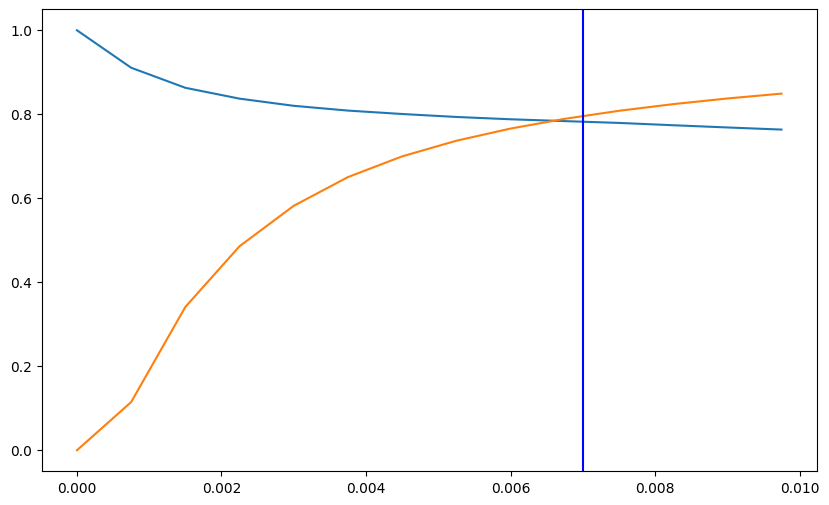

In [376]:
# проверяем насколько подобранный на основе нетестовых данных трешхолд близок к идеальному
thr = 0.007

plt.figure(figsize=(10, 6))

plt.plot(thrs_all, metrics['tpr'], label='TPR') 
plt.plot(thrs_all, metrics['tnr'], label='TNR')
plt.axvline(x=thr, color='b')